# Time Series Classification and Ensemble Methods

## Load dataset

In [ ]:
from importlib.util import find_spec

if not all(find_spec(pkg) for pkg in ['aeon', 'nonconformist']):
  !pip install aeon nonconformist

In [ ]:
from aeon.datasets import load_classification
import numpy as np

def load_dataset(dataset='binary'):
  if dataset == "binary":
    X, y = load_classification("ECG200")
  elif dataset == "multiclass":
    X, y = load_classification("SmoothSubspace")

  y_tmp = y.astype(int)
  if dataset == "multiclass":
    y_tmp -= 1

  return X[:, 0, :], y_tmp

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

def split_data(dataset='binary', train_size=0.55, val_size=0.20, cal_size=0.15, test_size=0.1, random_state=42):
    # Validate split ratios
    if not np.isclose(train_size + test_size + val_size + cal_size, 1.0):
        raise ValueError("Split proportions must sum to 1.0")

    # Load dataset
    X, y = load_dataset(dataset)

    # First split: separate train data
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        train_size=train_size,
        random_state=random_state
    )

    # Calculate remaining ratios
    remaining = test_size + val_size + cal_size
    test_ratio = test_size / remaining
    val_ratio = val_size / remaining

    # Second split: separate test data
    X_test, X_temp2, y_test, y_temp2 = train_test_split(
        X_temp, y_temp,
        train_size=test_ratio,
        random_state=random_state
    )

    # Final split: separate validation and calibration
    X_val, X_cal, y_val, y_cal = train_test_split(
        X_temp2, y_temp2,
        train_size=val_ratio/(val_ratio + cal_size),
        random_state=random_state
    )

    return {
        'train': (X_train, y_train),
        'test': (X_test, y_test),
        'calibration': (X_cal, y_cal),
        'validation': (X_val, y_val)
    }

In [ ]:
from nonconformist.base import ClassifierAdapter

class MyClassifierAdapter(ClassifierAdapter):
    def __init__(self, model, fit_params=None):
        super(MyClassifierAdapter, self).__init__(model, fit_params)

    def fit(self, x, y):
        self.model.fit(x,y)

    def predict(self, x):
        return self.model.predict_proba(x)

## Sequential Boost Classifier (SBC)
The Sequential Boost Classifier (SBC) is designed for time-series classification, combining weak learners sequentially with boosting. Here's how it works:

### Core Components:
1. **Weak Learners**: Defined as $h_i(x) = d_i \cdot \text{sgn}(t_i - x)$, where $t_i$ is the threshold and $d_i \in \{-1, 1\}$ indicates direction.
2. **Combination**: The final classifier aggregates weighted weak learners: $ H(x) = \text{sgn}(\sum_{i=0}^{m} \alpha_i \cdot h_i(x_i)) $.

### Training Process:
- Iteratively selects weak learners, adjusting weights $ \alpha_i $ to minimize errors on binary-labeled data $ Y \in \{-1, 1\} $.

In [ ]:
from sklearn.utils import resample

class SBC:
    def __init__(self, n_weak_learners=None):
        self.n_weak_learners = n_weak_learners
        self.alpha = None
        self.threshold = None
        self.direction = None
        self.class_label = None

    def _init_weak_learners(self, n_weak_learners):
        self.n_weak_learners = n_weak_learners
        self.alpha = np.zeros(n_weak_learners)
        self.threshold = np.zeros(n_weak_learners)
        self.direction = np.ones(n_weak_learners)

    def custom_sign(self, x):
        return np.where(x >= 0, 1, -1)

    def fit(self, X, Y, validation_set=None, target_acc=0.95):
        n_weak_learners = self.n_weak_learners or len(X[0])
        self._init_weak_learners(n_weak_learners)

        weights = np.ones(len(X)) / len(X)
        train_error = {'train': [], 'val': []}

        for i in range(self.n_weak_learners):
            best_learner, alpha = self.find_best_learner(X[:, i], Y, weights)
            self.threshold[i] = best_learner[0]
            self.direction[i] = best_learner[1]
            self.alpha[i] = alpha

            predictions = self.custom_sign(self.threshold[i] - X[:, i]) * self.direction[i]
            weights = self.update_weights(weights, Y, predictions)

            train_error['train'].append(self.performance(X, Y))
            if validation_set:
                perf = self.performance(*validation_set)
                train_error['val'].append(perf)
                if perf >= target_acc:
                    break

        return train_error

    def find_best_learner(self, Xi, Y, weights):
        best_learner, best_error = None, float('inf')
        total_weight = np.sum(weights)

        for th in np.unique(Xi):
            for d in [-1, 1]:
                predictions = self.custom_sign(th - Xi) * d
                error = np.sum(weights[predictions != Y]) / total_weight

                if error < best_error:
                    best_learner = (th, d)
                    best_error = error

        best_alpha = 0.5 * np.log((1 - best_error) / max(best_error, 1e-10))
        return best_learner, best_alpha

    def update_weights(self, weights, Y, predictions):
        correct_mask = predictions == Y
        d_top = np.sum(weights[correct_mask])
        direction_weight = np.where(correct_mask, d_top, 1 - d_top)
        return 0.5 * weights / direction_weight

    def predict(self, X, truncate=None):
        limit = truncate or self.n_weak_learners
        h = self.custom_sign(self.threshold[:limit] - X[:, :limit]) * self.direction[:limit]
        return self.custom_sign(np.sum(h * self.alpha[:limit], axis=1))

    def predict_proba(self, X, truncate=None):
        limit = truncate or self.n_weak_learners
        h = self.custom_sign(self.threshold[:limit] - X[:, :limit]) * self.direction[:limit]
        return np.sum(self.alpha[:limit] * (h == 1), axis=1) / np.sum(self.alpha[:limit])

    def performance(self, X, Y):
        predictions = self.predict(X)
        # compute as percentage
        return np.mean(predictions == Y)

### Binary dataset

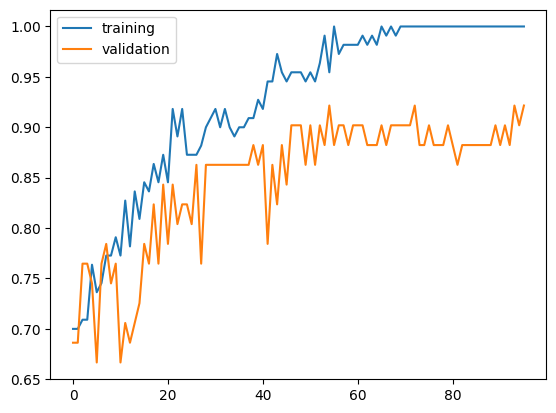

In [ ]:
import matplotlib.pyplot as plt

dataset = split_data('binary', val_size=0.25, cal_size=0.01, test_size=0.19)

X_train, y_train = dataset['train']
validation_set = dataset['validation']

sbc = SBC()
train_errors = sbc.fit(X_train, y_train, validation_set)

plt.plot(train_errors['train'], label='training')
plt.plot(train_errors['val'], label='validation')

plt.legend()

Accuracy: 0.789


<Axes: >

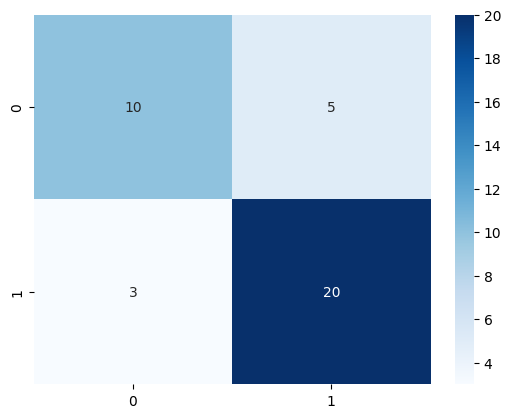

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

y_pred = sbc.predict(dataset['test'][0])
y_true = dataset['test'][1]

# Calculate accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.3f}")

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

## Bagging Ensemble of Sequential Boost Classifier (BE-SBC)
The **Bagging Ensemble of Sequential Boost Classifier (BE-SBC)** builds on SBC by aggregating multiple SBC classifiers trained on bootstrapped subsets of the data. Here are its key features:
1. **Training**:
   - A collection of SBC classifiers $( H_1, H_2, \ldots, H_n $) is trained using bootstrapped datasets.
   - Each SBC may have its own configuration (e.g., number of weak learners).
2. **Prediction**:
   - For **binary classification**, majority voting is used.
   - For **multiclass classification**, various voting schemes (majority, weighted, track record) determine class probabilities.

In [ ]:
class BESBC:
    def __init__(self, n_estimators=12, **sbc_params):
        self.n_estimators = n_estimators
        self.sbc_params = sbc_params
        self.estimators = []
        self.validation_accuracies = []
        self.validation_fnrs = []
        self.unique_classes = 0

    def fit(self, X, y, validation_set=None):
        self.unique_classes = np.unique(y)

        for _ in range(self.n_estimators):
            X_boot, y_boot = resample(X, y)
            selected_class = np.random.choice(self.unique_classes)

            y_binary = np.where(y_boot == selected_class, 1, -1)
            sbc = SBC(**self.sbc_params)
            sbc.class_label = selected_class
            sbc.fit(X_boot, y_binary)

            if validation_set:
                X_val, y_val = validation_set
                y_val_binary = np.where(y_val == selected_class, 1, -1)
                predictions = sbc.predict(X_val)
                acc = np.mean(predictions == y_val_binary)
                fnr = np.mean((predictions == -1) & (y_val_binary == 1))
                self.validation_accuracies.append(acc)
                self.validation_fnrs.append(fnr)

            self.estimators.append(sbc)

        return self.validation_accuracies

    def predict_proba(self, X, **args):
        result = self._predict_proba_raw(X, **args)

        normalize_vector = np.sum(result, axis=1)

        return result / normalize_vector[:, None]

    def _predict_proba_raw(self, X, method='majority'):
        print(method)
        if method == 'majority':
            return self._majority_voting(X)
        elif method == 'weighted':
            return self._weighted_voting(X)
        else:  # track_record
            return self._track_record_voting(X)

    def _majority_voting(self, X):
        # init result as array of shape len*classes
        result = np.zeros((len(X), len(self.unique_classes)))

        for est in self.estimators:
            result[:, est.class_label] += (est.predict(X) == 1).astype(int)

        return result

    def _weighted_voting(self, X):
        result = np.zeros((len(X), len(self.unique_classes)))

        # Initialize probabilities for each sample
        for est, acc in zip(self.estimators, self.validation_accuracies):
          result[:, est.class_label] += (est.predict(X) == 1) * acc

        return result

    def _track_record_voting(self, X):
        result = np.zeros((len(X), len(self.unique_classes)))

        for est, acc, fnr in zip(self.estimators, self.validation_accuracies, self.validation_fnrs):
          predictions = est.predict(X)
          weights = np.where(predictions == 1, acc, fnr)
          result[:, est.class_label] += weights

        return result

### Binary dataset

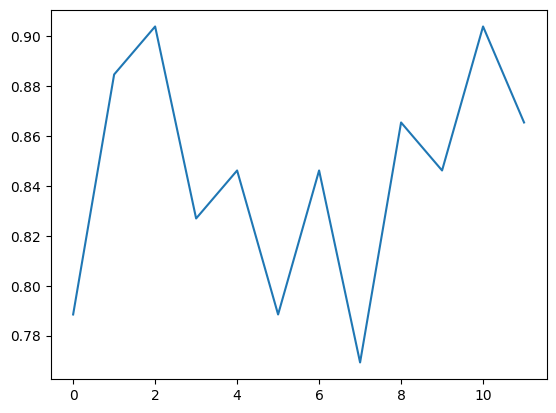

In [ ]:
import matplotlib.pyplot as plt

dataset = split_data('binary')

X_train, y_train = dataset['train']
y_train = np.where(y_train == 1, 1, 0)

X_val, y_val = dataset['validation']
y_val = np.where(y_val == 1, 1, 0)

besbc = BESBC()
train_error = besbc.fit(X_train, y_train, (X_val, y_val))

plt.plot(train_error)

majority
Accuracy: 0.750


<Axes: >

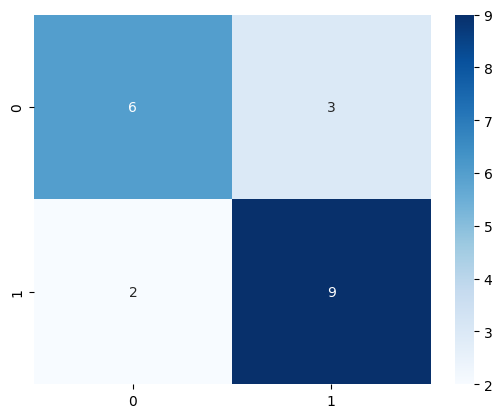

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

X_test, y_test = dataset['test']
y_test = np.where(y_test == 1, 1, 0)

# Get probability predictions
y_pred_proba = besbc.predict_proba(X_test)

# Convert probabilities to class predictions
y_pred = np.argmax(y_pred_proba, axis=1)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

In [ ]:
from nonconformist.cp import IcpClassifier
from nonconformist.nc import ClassifierNc

model = MyClassifierAdapter(besbc)
nc = ClassifierNc(model)
icp = IcpClassifier(nc)

In [ ]:
X_cal, y_cal = dataset['calibration']
y_cal = np.where(y_cal == 1, 1, 0)

# Calibrate conformal classifier
icp.calibrate(X_cal, y_cal)

majority


In [ ]:
X_test, y_test = dataset['test']
y_test = np.where(y_test == 1, 1, 0)

# Evaluate on test set
icp.predict(X_test, significance=0.1)

majority
majority


array([[False,  True],
       [ True,  True],
       [ True,  True],
       [ True, False],
       [ True,  True],
       [False,  True],
       [ True, False],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [ True,  True],
       [ True, False],
       [ True, False],
       [ True,  True],
       [ True, False],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True]])

### Multiclass dataset

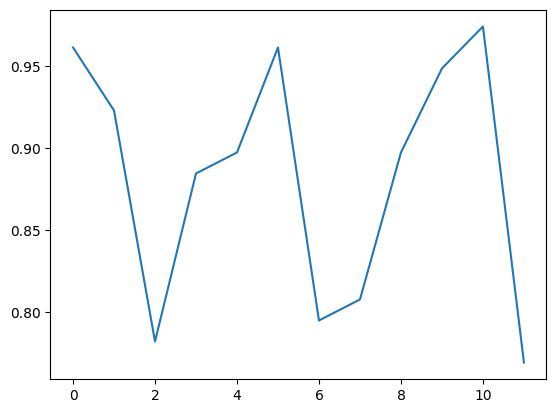

In [ ]:
import matplotlib.pyplot as plt

dataset = split_data('multiclass')

X_train, y_train = dataset['train']
validation = dataset['validation']

besbc = BESBC()
train_error = besbc.fit(X_train, y_train, validation)

plt.plot(train_error)

majority
Accuracy: 0.967
weighted
Accuracy: 0.967
track_record
Accuracy: 0.967


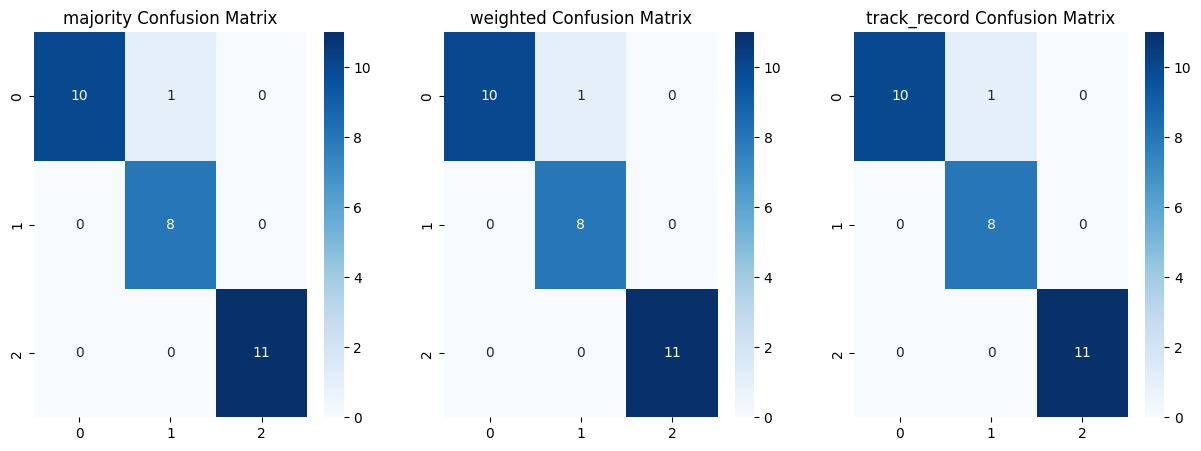

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

X_test, y_test = dataset['test']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, method in zip(axes, ['majority', 'weighted', 'track_record']):
    # Get probability predictions
    y_pred_proba = besbc.predict_proba(X_test, method=method)

    # Convert probabilities to class predictions
    y_pred = np.argmax(y_pred_proba, axis=1)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.3f}")

    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    heatmap = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)

    ax.set_title(f'{method} Confusion Matrix')

In [ ]:
from nonconformist.cp import IcpClassifier
from nonconformist.nc import ClassifierNc

model = MyClassifierAdapter(besbc)
nc = ClassifierNc(model)
icp = IcpClassifier(nc)

In [ ]:
X_cal, y_cal = dataset['calibration']

icp.calibrate(X_cal, y_cal)

majority


<ipython-input-205-8f579dbed019>:40: RuntimeWarning: invalid value encountered in divide
  return result / normalize_vector[:, None]


In [ ]:
X_test, y_test = dataset['test']

# Evaluate on test set
icp.predict(X_test, significance=0.05)

majority
majority
majority


array([[ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True, False],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True, False,  True],
       [False,  True,  True],
       [False, False,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [False,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True, False,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True, False,  True],
       [ True,  True,  True],
       [ True,  True,  True]])

## SBC-based Isolation-like Ensemble (I-SBC)

The SBC-based Isolation-like Ensemble (I-SBC) extends SBC to anomaly detection and distance-based analysis in an unsupervised learning framework.
1. **Learning Process**:
   - Utilizes an ensemble of SBC classifiers.
   - Operates on an unlabeled dataset \( X \).
   - Configurable ensemble size \( n\_estimators \).

2. **Distance Measures**:
   - Computes similarity and distances between sequences:
     - **Breiman-like**: Measures behavioral consistency.
     - **Zhu-like**: Evaluates matching decision sequences.
     - **Ratio-like**: Considers proportions of matching decisions.

In [ ]:
class ISBC:
    def __init__(self, n_estimators=10, **sbc_params):
        self.n_estimators = n_estimators
        self.sbc_params = sbc_params
        self.estimators = []

    def fit(self, X):
        for _ in range(self.n_estimators):
            X_sample = resample(X)
            y_random = np.random.choice([-1, 1], size=len(X_sample))

            sbc = SBC(**self.sbc_params)
            sbc.fit(X_sample, y_random)
            self.estimators.append(sbc)
        return self

    def breiman_distance(self, x1, x2):
        matching = 0
        for est in self.estimators:
            preds1 = [est.custom_sign(t - x) * d for t, d, x in
                     zip(est.threshold, est.direction, x1)]
            preds2 = [est.custom_sign(t - x) * d for t, d, x in
                     zip(est.threshold, est.direction, x2)]
            if all(p1 == p2 for p1, p2 in zip(preds1, preds2)):
                matching += 1
        return 1 - (matching / self.n_estimators)

    def zhu_distance(self, x1, x2):
        total_prefix = 0
        total_length = 0

        for est in self.estimators:
            prefix_length = 0
            for t, d, x1_val, x2_val in zip(est.threshold, est.direction, x1, x2):
                pred1 = est.custom_sign(t - x1_val) * d
                pred2 = est.custom_sign(t - x2_val) * d
                if pred1 != pred2:
                    break
                prefix_length += 1

            total_prefix += prefix_length
            total_length += len(est.threshold)

        return 1 - (total_prefix / total_length)

    def ratio_distance(self, x1, x2):
        matching = 0
        total = 0

        for est in self.estimators:
            for t, d, x1_val, x2_val in zip(est.threshold, est.direction, x1, x2):
                pred1 = est.custom_sign(t - x1_val) * d
                pred2 = est.custom_sign(t - x2_val) * d
                matching += int(pred1 == pred2)
                total += 1

        return 1 - (matching / total)

In [ ]:
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform, pdist

def evaluate_clustering(X, y_true=None, n_estimators=10, n_clusters=3):
    # Train I-SBC ensemble
    isbc = ISBC(n_estimators=n_estimators)
    isbc.fit(X)

    # Calculate distance matrices for each measure
    n_samples = len(X)
    distance_matrices = {
        'breiman': np.zeros((n_samples, n_samples)),
        'zhu': np.zeros((n_samples, n_samples)),
        'ratio': np.zeros((n_samples, n_samples))
    }

    # Populate distance matrices
    for i in range(n_samples):
        for j in range(i+1, n_samples):
            distance_matrices['breiman'][i,j] = isbc.breiman_distance(X[i], X[j])
            distance_matrices['zhu'][i,j] = isbc.zhu_distance(X[i], X[j])
            distance_matrices['ratio'][i,j] = isbc.ratio_distance(X[i], X[j])

            # Mirror the matrices
            distance_matrices['breiman'][j,i] = distance_matrices['breiman'][i,j]
            distance_matrices['zhu'][j,i] = distance_matrices['zhu'][i,j]
            distance_matrices['ratio'][j,i] = distance_matrices['ratio'][i,j]

    results = {}
    for method, dist_matrix in distance_matrices.items():
        # Perform clustering using the distance matrix
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        cluster_labels = kmeans.fit_predict(dist_matrix)

        # Internal metric: Intra/Inter cluster distance ratio
        intra_cluster = 0
        inter_cluster = 0
        cluster_centers = []

        # Calculate cluster centers
        for k in range(n_clusters):
            mask = cluster_labels == k
            if np.sum(mask) > 0:
                cluster_centers.append(np.mean(dist_matrix[mask][:, mask], axis=(0, 1)))

        # Calculate intra-cluster distances
        for k in range(n_clusters):
            mask = cluster_labels == k
            if np.sum(mask) > 1:
                intra_cluster += np.sum(dist_matrix[mask][:, mask]) / (2 * np.sum(mask))

        # Calculate inter-cluster distances
        for i in range(n_clusters):
            for j in range(i+1, n_clusters):
                mask_i = cluster_labels == i
                mask_j = cluster_labels == j
                if np.sum(mask_i) > 0 and np.sum(mask_j) > 0:
                    inter_cluster += np.mean(dist_matrix[mask_i][:, mask_j])

        intra_inter_ratio = intra_cluster / (inter_cluster + 1e-10)

        # External metric: Geometric Index (GI)
        if y_true is not None:
            unique_classes = np.unique(y_true)
            intra_class = 0
            inter_class = 0

            # Calculate intra-class distances
            for c in unique_classes:
                mask = y_true == c
                if np.sum(mask) > 1:
                    intra_class += np.sum(dist_matrix[mask][:, mask]) / (2 * np.sum(mask))

            # Calculate inter-class distances
            for i in range(len(unique_classes)):
                for j in range(i+1, len(unique_classes)):
                    mask_i = y_true == unique_classes[i]
                    mask_j = y_true == unique_classes[j]
                    if np.sum(mask_i) > 0 and np.sum(mask_j) > 0:
                        inter_class += np.mean(dist_matrix[mask_i][:, mask_j])

            gi = intra_class / (inter_class + 1e-10)
        else:
            gi = None

        results[method] = {
            'intra_inter_ratio': intra_inter_ratio,
            'gi': gi
        }

    return results, distance_matrices

def plot_distance_matrices(distance_matrices):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, (method, matrix) in zip(axes, distance_matrices.items()):
        im = ax.imshow(matrix, cmap='viridis')
        ax.set_title(f'{method.capitalize()} Distance Matrix')
        plt.colorbar(im, ax=ax)

    plt.tight_layout()
    return fig

### Binary dataset

In [ ]:
X_train, y_train = split_data('binary', train_size=0.97, test_size=0.01, cal_size=0.01, val_size=0.01)['train']
y_train = np.where(y_train == 1, 1, 0)

In [ ]:
# Evaluate clustering
results, dist_matrices = evaluate_clustering(X_train, y_train, n_clusters=2)


Breiman distances:
Inter/Intra score: 96.000
GI: 96.000

Zhu distances:
Inter/Intra score: 94.366
GI: 95.348

Ratio distances:
Inter/Intra score: 65.611
GI: 79.214


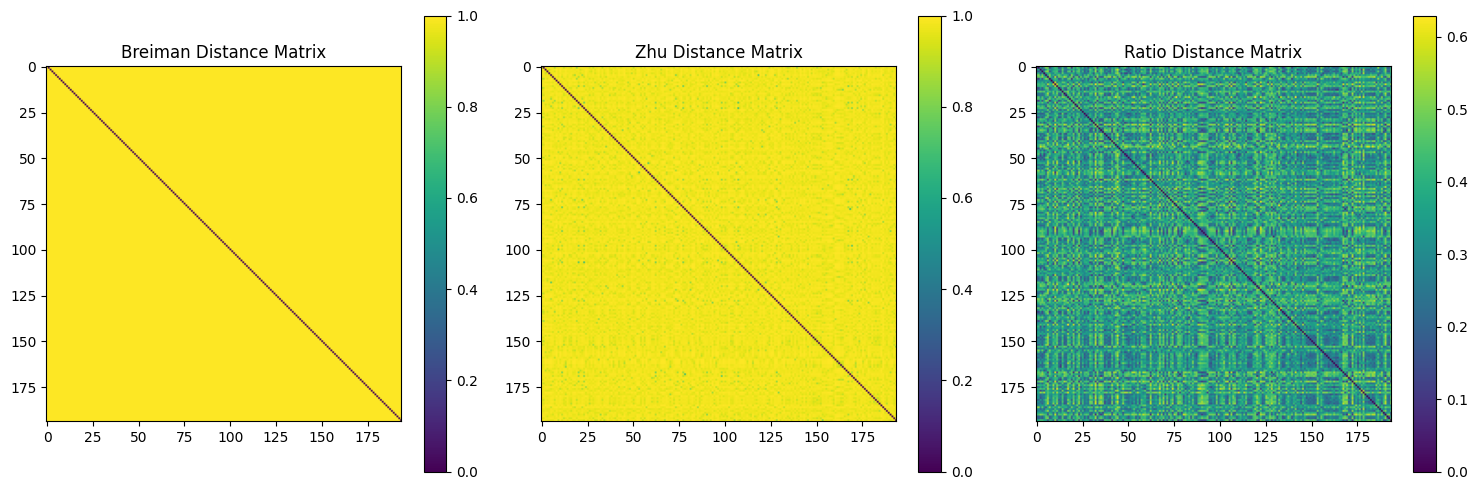

In [ ]:
# Print results
for method, metrics in results.items():
    print(f"\n{method.capitalize()} distances:")
    print(f"Inter/Intra score: {metrics['intra_inter_ratio']:.3f}")
    print(f"GI: {metrics['gi']:.3f}")

# Plot distance matrices
plot_distance_matrices(dist_matrices)
plt.show()

### Multiclass dataset

In [ ]:
X_train, y_train = split_data('multiclass', train_size=0.97, test_size=0.01, cal_size=0.01, val_size=0.01)['train']

In [ ]:
# Evaluate clustering
results, dist_matrices = evaluate_clustering(X_train, y_train)


Breiman distances:
Inter/Intra score: 47.732
GI: 47.859

Zhu distances:
Inter/Intra score: 43.596
GI: 46.138

Ratio distances:
Inter/Intra score: 37.890
GI: 37.862


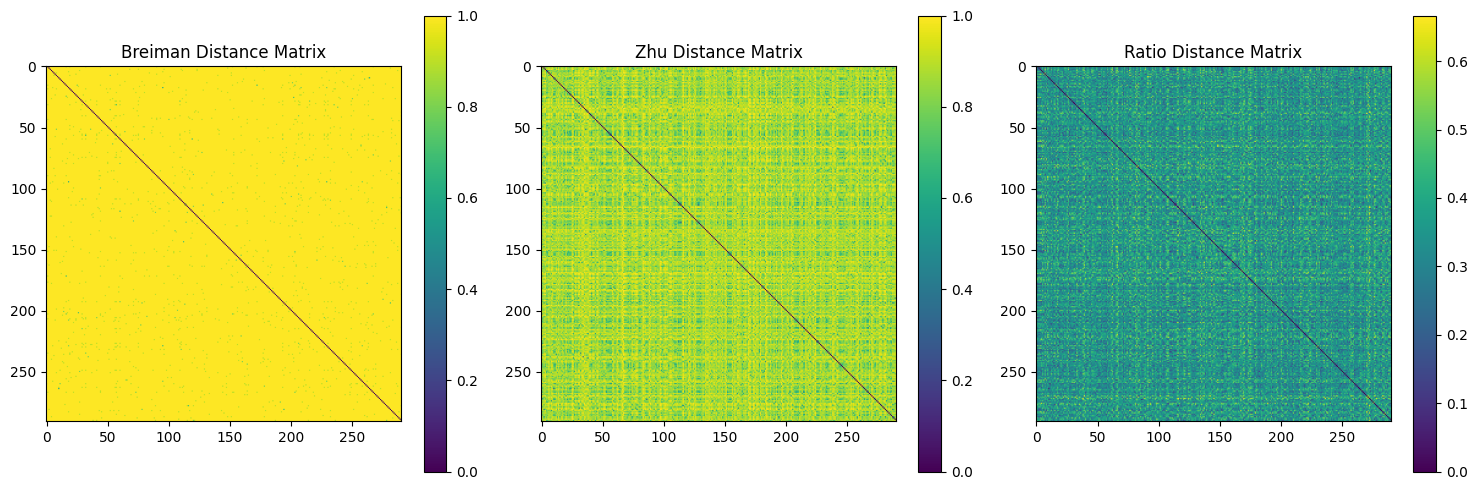

In [ ]:
# Print results
for method, metrics in results.items():
    print(f"\n{method.capitalize()} distances:")
    print(f"Inter/Intra score: {metrics['intra_inter_ratio']:.3f}")
    print(f"GI: {metrics['gi']:.3f}")

# Plot distance matrices
plot_distance_matrices(dist_matrices)
plt.show()

## I-SBC Nearest Neighbor Classifier (I-SBC-NN)
The **I-SBC Nearest Neighbor Classifier (I-SBC-NN)** is a supervised classifier that extends the I-SBC framework for distance-based classification.

### Key Features of I-SBC-NN:
1. **Distance Measure**:
   - Utilizes I-SBC distance measures (Breiman, Zhu, or Ratio) to calculate proximity between samples.
   
2. **Nearest Neighbor Approach**:
   - For a given input \( x \), finds the nearest training sample \( x_{c_k} \) for each class \( c_k \).
   - \( x_{c_k} = \text{argmin}_{x' \in X: y(x') = c_k} d(x, x') \).

3. **Probability Distribution**:
   - Computes probabilities for each class using the distances:
     \[
     P(c_k | x) = \frac{1 - d(x, x_{c_k})}{\sum_{j=1}^{l} (1 - d(x, x_{c_j}))}
     \]

In [ ]:
class ISBCNN:
    def __init__(self, n_estimators=10, n_weak_learners=None):
        self.n_estimators = n_estimators
        self.n_weak_learners = n_weak_learners
        self.isbc = None
        self.X_train = None
        self.y_train = None
        self.classes_ = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        self.classes_ = np.unique(y)

        self.isbc = ISBC(n_estimators=self.n_estimators,
                        n_weak_learners=self.n_weak_learners)
        self.isbc.fit(X)
        return self

    def _get_distance(self, x1, x2, distance_metric='ratio'):
        if distance_metric == 'breiman':
            return self.isbc.breiman_distance(x1, x2)
        elif distance_metric == 'zhu':
            return self.isbc.zhu_distance(x1, x2)
        else:  # ratio
            return self.isbc.ratio_distance(x1, x2)

    def predict_proba(self, X, **kwargs):
        probs = np.zeros((len(X), len(self.classes_)))

        for i, x in enumerate(X):
            for c in self.classes_:
                mask = self.y_train == c
                if np.any(mask):
                    distances = [self._get_distance(x, x_train, **kwargs)
                               for x_train in self.X_train[mask]]
                    probs[i, c] = min(distances)

        probs = 1 - probs
        denominator = np.sum(probs, axis=1)

        return probs / denominator[:, None]

### Binary dataset


In [ ]:
dataset = split_data('binary')

In [ ]:
X_train, y_train = dataset['train']
y_train = np.where(y_train == 1, 1, 0)

isbc_nn = ISBCNN()
isbc_nn.fit(X_train, y_train)

<ipython-input-224-5fd43688e017>:42: RuntimeWarning: invalid value encountered in divide
  return probs / denominator[:, None]


Accuracy: 0.450
Accuracy: 0.900
Accuracy: 0.950


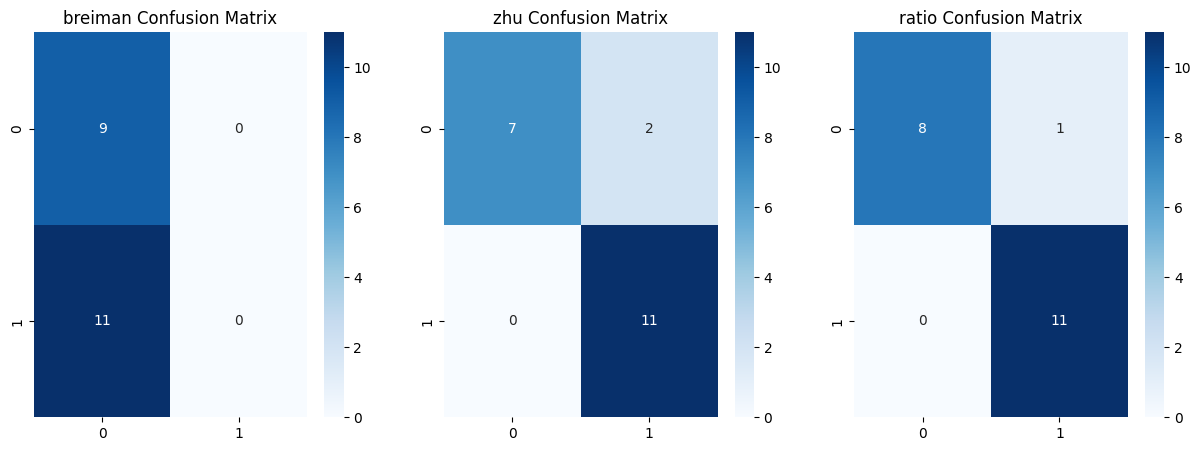

In [ ]:
X_test, y_test = dataset['test']
y_test = np.where(y_test == 1, 1, 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, distance_metric in zip(axes, ['breiman', 'zhu', 'ratio']):
    # Get probability predictions
    y_pred_proba = isbc_nn.predict_proba(X_test, distance_metric=distance_metric)

    # Convert probabilities to class predictions
    y_pred = np.argmax(y_pred_proba, axis=1)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{distance_metric} Accuracy: {accuracy:.3f}")

    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    heatmap = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)

    ax.set_title(f'{distance_metric} Confusion Matrix')

In [ ]:
from nonconformist.cp import IcpClassifier
from nonconformist.nc import ClassifierNc

model = MyClassifierAdapter(isbc_nn)
nc = ClassifierNc(model)
icp = IcpClassifier(nc)

In [ ]:
X_cal, y_cal = dataset['calibration']
y_cal = np.where(y_cal == 1, 1, 0)

icp.calibrate(X_cal, y_cal)

In [ ]:
# Evaluate on test set
icp.predict(X_test, significance=0.05)

array([[False,  True],
       [ True, False],
       [ True, False],
       [False,  True],
       [ True, False],
       [ True,  True],
       [ True, False],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [ True, False],
       [ True,  True],
       [ True, False],
       [ True, False],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True]])

### Multiclass dataset

In [ ]:
dataset = split_data('multiclass')

In [ ]:
X_train, y_train = dataset['train']

isbc_nn = ISBCNN()
isbc_nn.fit(X_train, y_train)

<ipython-input-224-5fd43688e017>:42: RuntimeWarning: invalid value encountered in divide
  return probs / denominator[:, None]


Accuracy: 0.633
Accuracy: 0.800
Accuracy: 0.900


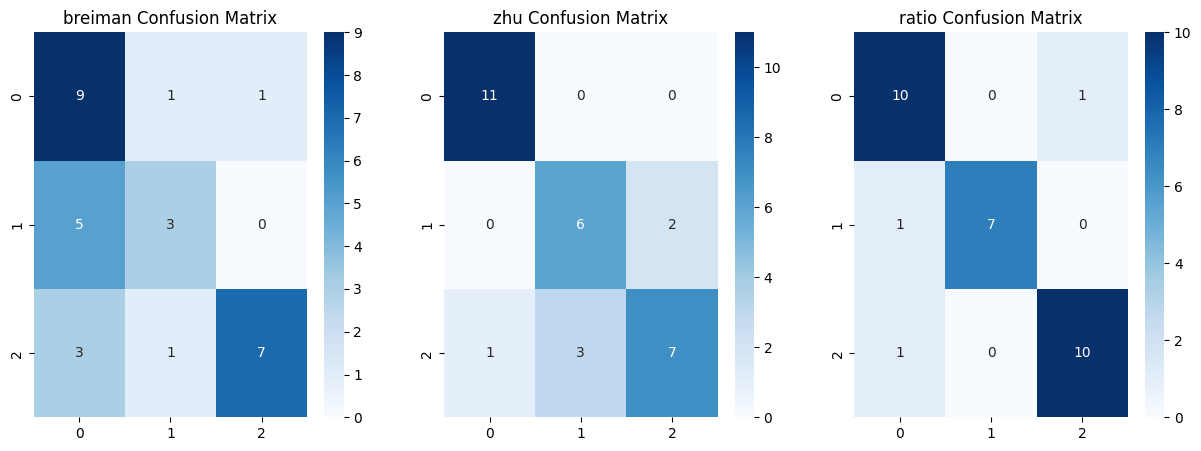

In [ ]:
X_test, y_test = dataset['test']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, distance_metric in zip(axes, ['breiman', 'zhu', 'ratio']):
    # Get probability predictions
    y_pred_proba = isbc_nn.predict_proba(X_test, distance_metric=distance_metric)

    # Convert probabilities to class predictions
    y_pred = np.argmax(y_pred_proba, axis=1)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.3f}")

    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    heatmap = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)

    ax.set_title(f'{distance_metric} Confusion Matrix')

In [ ]:
from nonconformist.cp import IcpClassifier
from nonconformist.nc import ClassifierNc

model = MyClassifierAdapter(isbc_nn)
nc = ClassifierNc(model)
icp = IcpClassifier(nc)

In [ ]:
X_cal, y_cal = dataset['calibration']

icp.calibrate(X_cal, y_cal)

In [ ]:
X_test, y_test = dataset['test']

# Evaluate on test set
icp.predict(X_test, significance=0.05)

array([[ True, False,  True],
       [False, False,  True],
       [ True,  True,  True],
       [ True, False, False],
       [False,  True, False],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True, False,  True],
       [False, False,  True],
       [ True,  True, False],
       [ True, False,  True],
       [ True, False, False],
       [False, False,  True],
       [ True, False, False],
       [ True,  True, False],
       [False, False,  True],
       [ True,  True,  True],
       [False, False,  True],
       [False,  True,  True],
       [False, False,  True],
       [ True,  True, False],
       [ True,  True, False],
       [False,  True,  True],
       [ True,  True, False],
       [False, False,  True],
       [ True, False,  True],
       [ True, False,  True],
       [ True,  True, False],
       [ True, False, False]])